In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import norm as scipy_normal

In [16]:
# Override ugly matplotlib defaults
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linewidth": 0.8,
    "font.size": 12,
})

This is a Normal-Normal model to predict water usage in an imaginary person. From a quick google search, it seems like the average person uses 82-100 gallons of water per day, distributed normally—so we will use the mean and standard deviation of this N(91, 2.5) as our prior.

We assume the variance to be 3 for the likelihood, and simulate the data with mean at 70 gallons. This person is trying to conserve some water, so they use less overall than the statistics I found on the internet.

It was hard for them to track how much water they use every day, so they ended up only sticking with tracking it for a week, resulting in 7 data points.

Since both the real water usage and the prior are normal distributions, we use the Normal-Normal conjugate model, resulting in also a normal posterior distribution. I use the mean and standard deviation given in the wikipedia table at https://en.wikipedia.org/wiki/Conjugate_prior, which is confirmed by solving the equation by hand as well for the multiplication of normal distributions.

In [54]:
# Mock data ~ N(55,3) where 3 is the std
mu = 70
sigma = 3
data = np.random.normal(loc=mu, scale=sigma, size=7)
N = data.size
y = data.sum()

# Prior hyperparameters 
# I took these from the average daily water usage in gallons
mu0, sigma0 = 91, 2.5

# Posterior hyperparameters (following conjugate update from wikipedia page)
sigma_post  = (1 / (1 / sigma0**2 + N / sigma**2) )
mu_post = sigma_post * (mu0 / sigma0**2 + sum(data) / sigma**2)

print(f"posterior mean = {mu_post}")
print(f"posterior sigma = {sigma_post}")

posterior mean = 73.84208164585702
posterior sigma = 1.066350710900474


In [58]:
# Obtain density values
theta_domain = np.linspace(65 + 1e-4, 100 - 1e-4, 2000) # Not put absolute zero for boundary problems
prior_pdf = scipy_normal.pdf(theta_domain, loc=mu0, scale=sigma0)
post_pdf  = scipy_normal.pdf(theta_domain, loc=mu_post, scale=sigma_post)

In [59]:
post_pdf

array([4.39774460e-016, 5.03846865e-016, 5.77098620e-016, ...,
       1.81229911e-131, 1.21195334e-131, 8.10260827e-132], shape=(2000,))

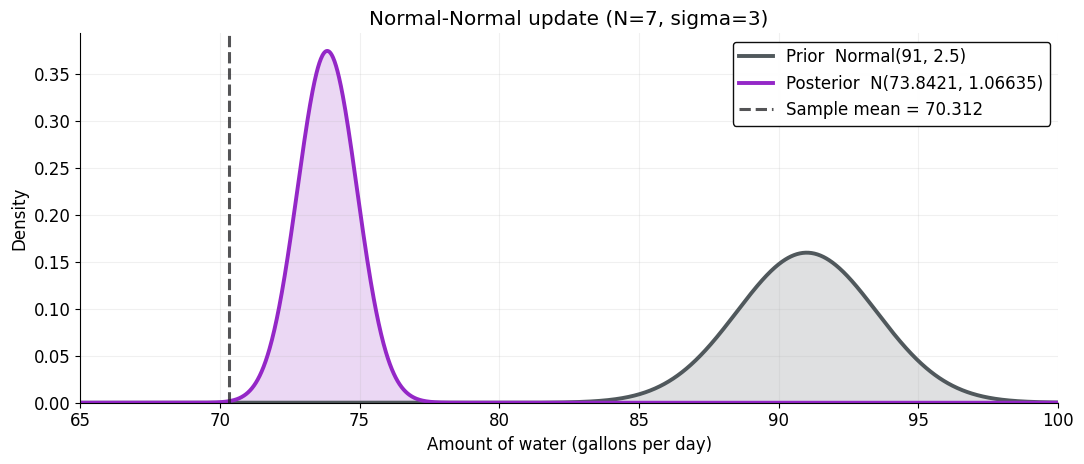

In [61]:
fig, ax = plt.subplots(figsize=(11, 4.8))

prior_color = "#50585C"
post_color  = "#9427C7"
mle_color   = "#1B1B1E" 
pmean_color = "#9427C7"

ax.plot(theta_domain, prior_pdf, lw=2.8, color=prior_color, label=fr"Prior  Normal({mu0:g}, {sigma0:g})")
ax.fill_between(theta_domain, 0, prior_pdf, color=prior_color, alpha=0.18)

ax.plot(theta_domain, post_pdf, lw=2.8, color=post_color,
        label=fr"Posterior  N({mu_post:g}, {sigma_post:g})")
ax.fill_between(theta_domain, 0, post_pdf, color=post_color, alpha=0.18)


mle = np.mean(data)
#post_mean = alpha_post / (alpha_post + beta_post)

ax.axvline(mle, color=mle_color, lw=2.2, ls="--", alpha=0.75, label=f"Sample mean = {mle:.3f}")
# ax.axvline(post_mean, color=pmean_color, lw=2.2, ls=":",  alpha=0.9,  label=f"Posterior mean = {post_mean:.3f}")

ax.set_xlim(65, 100)
ax.set_ylim(0, None)
ax.set_xlabel(r"Amount of water (gallons per day)")
ax.set_ylabel("Density")
# ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title(f"Normal-Normal update (N={N}, sigma={sigma})")
ax.legend(frameon=True, framealpha=0.95, facecolor="white", edgecolor=(0, 0, 0, 0.12))

fig.tight_layout()

From this plot, we can see that there is a lot of information we gained from the analysis, even with just 7 datapoints (seven months of simulated water usage data). In this case, the real mean usage is about 70 gallons per day. But because the average usage is so high (91 gallons per day), it is still prudent to budget for a bit more at this point. We could use the posterior mean or perhaps the point where we have 90% cdf for the posterior distribution to calculate the budget-- to be safe, but not set aside too much money for it.